In [1]:
print("Welcome to the DFUC2020 Project")

Welcome to the DFUC2020 Project


In [2]:
#Author: Subbulakshmi Meena
#Dataset: DFUC2020 MICCAI Challenge

In [5]:
# import required libraries 
import os 
import cv2
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [6]:
# ==============================
# Dataset Paths
# ==============================

project_path = r"D:\DFUC_Project"

dataset_path = os.path.join(project_path, "Dataset", "DFUC2020")

train_image_path = os.path.join(
    dataset_path,
    "DFUC_Training_Set",
    "images"
)

annotation_path = os.path.join(
    dataset_path,
    "DFUC_Training_Set",
    "groundtruth.csv"
)

print("Project Path :", project_path)
print("Dataset Path :", dataset_path)
print("Training Images :", train_image_path)
print("Annotation File :", annotation_path)

Project Path : D:\DFUC_Project
Dataset Path : D:\DFUC_Project\Dataset\DFUC2020
Training Images : D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\images
Annotation File : D:\DFUC_Project\Dataset\DFUC2020\DFUC_Training_Set\groundtruth.csv


In [7]:
# ==============================
# Load Annotation CSV
# ==============================

annotations = pd.read_csv(annotation_path)

print("Annotation file loaded successfully!")

Annotation file loaded successfully!


In [8]:
# Display first 10 rows

annotations.head(10)

,filename,xmin,ymin,xmax,ymax
0,100001,270,186,303,239
1,100001,37,176,123,256
2,100002,57,203,178,310
3,100003,267,151,317,203
4,100004,271,163,327,205
5,100005,123,115,292,359
6,100006,99,51,503,440
7,100007,278,233,329,281
8,100008,95,20,586,379
9,100009,186,282,245,340


In [9]:
# Number of annotations

print("Total annotations :", len(annotations))

Total annotations : 2496


In [10]:
# Number of unique images

print("Total images :", annotations["filename"].nunique())

Total images : 2000


In [11]:
# ==============================
# Show First Training Image
# ==============================

image_files = os.listdir(train_image_path)

print("Number of image files :", len(image_files))

print("First image :", image_files[0])

Number of image files : 2000
First image : 100001.jpg


In [12]:
# ==============================
# Read First Image
# ==============================

image_name = image_files[0]

image_path = os.path.join(train_image_path, image_name)

image = cv2.imread(image_path)

print(image.shape)

(480, 640, 3)


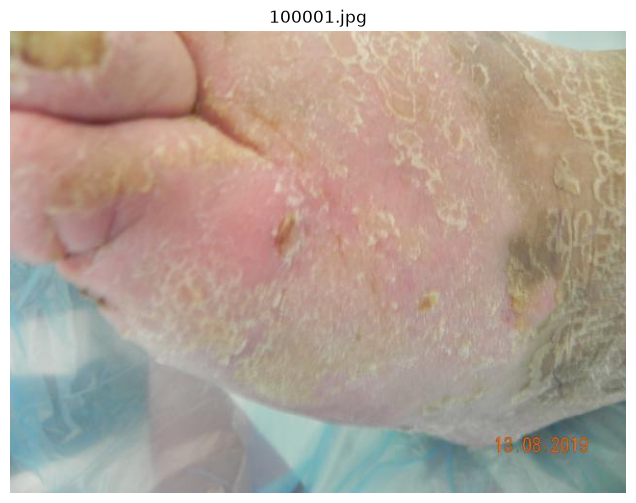

In [13]:
# ==============================
# Display Image
# ==============================

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.title(image_name)
plt.axis("off")

plt.show()

In [14]:
# ==============================
# Get Bounding Boxes for One Image
# ==============================

image_name_without_extension = image_name.replace(".jpg", "")

image_boxes = annotations[
    annotations["filename"] == int(image_name_without_extension)
]

image_boxes

,filename,xmin,ymin,xmax,ymax
0,100001,270,186,303,239
1,100001,37,176,123,256


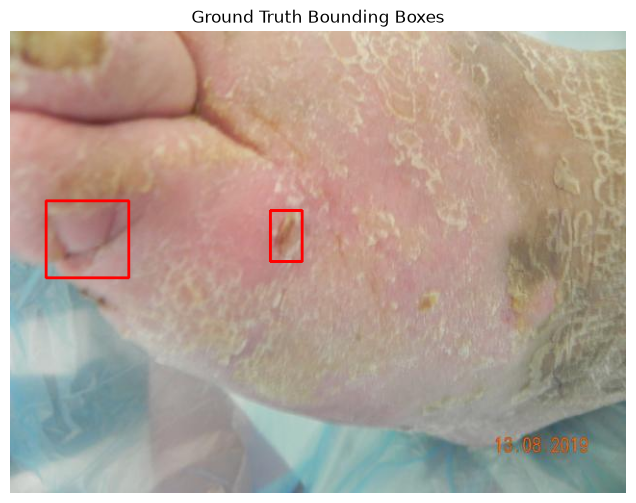

In [15]:
# ==============================
# Draw Bounding Boxes
# ==============================

# Make a copy of the image
image_copy = image_rgb.copy()

# Draw every bounding box
for index, row in image_boxes.iterrows():

    xmin = int(row["xmin"])
    ymin = int(row["ymin"])
    xmax = int(row["xmax"])
    ymax = int(row["ymax"])

    cv2.rectangle(
        image_copy,
        (xmin, ymin),
        (xmax, ymax),
        (255, 0, 0),
        2
    )

# Display image
plt.figure(figsize=(8,6))
plt.imshow(image_copy)
plt.title("Ground Truth Bounding Boxes")
plt.axis("off")
plt.show()

In [17]:
# Notebook 01 Summary

#Successfully loaded the DFUC2020 dataset.

# Successfully loaded the annotation CSV file.

# Verified that the dataset contains 2000 training images.

# Verified that there are 2496 bounding box annotations.

# Verified that one image may contain multiple ulcers.

# Successfully displayed the image.

# Successfully displayed the ground truth bounding boxes.

# Notebook 01 completed successfully.